# Round 3 - Signal Tracking: Real-Time Analysis

**Competition:** Data Vortex | AARUUSH'26  **Theme:** Rebuilding the Social Engine
**Team:** Entropy  **Members:** Saanvi Grover & Aditya Sharma

**Assigned topic:** Public Reaction to a Major Software Update
**Event tracked:** the **iOS 27 / iPadOS 27 / macOS 27** release (14 September 2026), with **Android 17** (18 September 2026) as a comparison release.

This notebook loads the self-collected dataset produced by `Entropy_collect_data.py`, applies the **Round 2 sentiment model** unchanged, and then answers the four questions the round asks for:

1. **Activity** - when did people post, and where are the spikes?
2. **Sentiment** - how did the balance of opinion move, and when did it shift?
3. **Topics and entities** - what exactly are people talking about?
4. **Triggers** - which real events explain the spikes and shifts?

In [1]:
import os, sys, json, re, warnings, time
from pathlib import Path
warnings.filterwarnings("ignore")
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter
from scipy import stats
from sklearn.decomposition import NMF
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

ROOT = Path.cwd()
DATA, IMG, OUT = ROOT / "data", ROOT / "images", ROOT / "outputs"
for p in (IMG, OUT):
    p.mkdir(exist_ok=True)
R2 = ROOT.parent / "Round2-Semantic-Recovery"
sys.path.insert(0, str(R2))
import Entropy_nlp_utils as nu   # the Round 2 module, unchanged

SEED = 42
N_BOOT = 2000
np.random.seed(SEED)
RESCORE = os.environ.get("ENTROPY_RESCORE", "0") == "1"
SCORED = OUT / "Entropy_round3_scored_posts.csv"
LAUNCH = {"iOS 27": pd.Timestamp("2026-09-14 17:00", tz="UTC"), "Android 17": pd.Timestamp("2026-09-18 17:00", tz="UTC")}
METRICS = {}

SURF, INK, INK2, MUTED, GRID, BASE = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SLOTS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
S1, S2 = SLOTS[0], SLOTS[1]
SENT = {"Negative": "#e34948", "Neutral": "#8f8d86", "Positive": "#2a78d6"}
plt.rcParams.update({
    "font.family": ["Segoe UI", "DejaVu Sans"], "font.size": 9.5, "figure.dpi": 110,
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF, "savefig.dpi": 200,
    "axes.edgecolor": BASE, "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "legend.frameon": False, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.titlecolor": INK,
})
def save(fig, name):
    fig.savefig(IMG / f"Entropy_r3_{name}.png", bbox_inches="tight")
    plt.show()
print("Round 2 module:", nu.__file__)

Round 2 module: C:\Users\Saanvi\Desktop\Data Vortex\Round2-Semantic-Recovery\Entropy_nlp_utils.py


## 1. Data collection method and dataset structure

The collector (`Entropy_collect_data.py`) is a plain-Python script using only free, key-less public endpoints. The manifest it writes records exactly what was requested and when.

In [2]:
manifest = json.loads((DATA / "Entropy_round3_collection_manifest.json").read_text(encoding="utf-8"))
raw = pd.read_csv(DATA / "Entropy_round3_collected_posts.csv")
news = pd.read_csv(DATA / "Entropy_round3_news_timeline.csv")
# parse_dates can silently leave mixed-offset timestamps as strings, so convert explicitly
raw["created_utc"] = pd.to_datetime(raw.created_utc, format="mixed", utc=True)
news["published_utc"] = pd.to_datetime(news.published_utc, format="mixed", utc=True)
keys = ["topic", "started_utc", "finished_utc", "requests", "failed_requests", "rows_raw",
        "rows_fetched_this_run", "rows_final", "append_mode", "reddit_popularity_pass",
        "unique_authors", "news_articles", "time_span"]
print(json.dumps({k: manifest[k] for k in keys if k in manifest}, indent=2))
structure = pd.DataFrame({
    "endpoint": ["www.reddit.com/*/search.rss, /comments/*.rss", "hn.algolia.com/api/v1/search",
                 "{instance}/api/v1/timelines/tag/{tag}", "{instance}/api/v3/search", "news.google.com/rss/search"],
    "auth": ["none (anonymous Atom)", "none", "none", "none", "none"],
    "engagement field": ["not exposed by RSS", "points, num_comments", "favourites + reblogs, replies", "score, comments", "n/a (event timeline)"],
}, index=["reddit", "hackernews", "mastodon", "lemmy", "googlenews"])
display(structure)
display(raw.groupby(["source", "kind"]).size().unstack(fill_value=0))
display(raw[["source", "source_detail", "kind", "created_utc", "title", "text", "score", "n_replies", "query"]].head(4))

{
  "topic": "Public reaction to a major software update: iOS 27 / iPadOS 27 / macOS 27, with Android 17 as comparison",
  "started_utc": "2026-09-20T10:33:04.228439+00:00",
  "finished_utc": "2026-09-20T11:42:12.724645+00:00",
  "requests": 199,
  "failed_requests": 19,
  "rows_raw": 9861,
  "rows_fetched_this_run": 6379,
  "rows_final": 5498,
  "append_mode": true,
  "reddit_popularity_pass": 12,
  "unique_authors": 3271,
  "news_articles": 388,
  "time_span": {
    "first": "2026-09-08 01:10:09+00:00",
    "last": "2026-09-20 11:38:50+00:00"
  }
}


,endpoint,auth,engagement field
reddit,"www.reddit.com/*/search.rss, /comments/*.rss",none (anonymous Atom),not exposed by RSS
hackernews,hn.algolia.com/api/v1/search,none,"points, num_comments"
mastodon,{instance}/api/v1/timelines/tag/{tag},none,"favourites + reblogs, replies"
lemmy,{instance}/api/v3/search,none,"score, comments"
googlenews,news.google.com/rss/search,none,n/a (event timeline)


kind,comment,post
source,,
hackernews,1919,126
lemmy,29,88
mastodon,0,1594
reddit,688,1054


,source,source_detail,kind,created_utc,title,text,score,n_replies,query
0,hackernews,story,post,2026-09-08 01:10:09+00:00,Show HN: Browse 27 years of movie ticket stubs...,This is one of those projects that&#x27;s been...,2.0,0.0,iOS 27
1,hackernews,story,post,2026-09-08 01:41:59+00:00,"I killed every houseplant I owned, so I built ...",I&#x27;ve killed more houseplants than I&#x27;...,2.0,3.0,Android 17
2,hackernews,comment,comment,2026-09-08 02:19:03+00:00,NaN,URL? Some photos of the corpses? Indoor or bal...,NaN,NaN,comment_thread
3,reddit,r/apple,comment,2026-09-08 02:38:23+00:00,NaN,I really am itching for a new form factor iPho...,NaN,NaN,comment_thread


In [3]:
def ascii_ratio(s):
    s = str(s)
    return sum(ch.isascii() for ch in s) / max(len(s), 1)

BOILERPLATE = re.compile(r"submitted by\s*/?u?/?\S*|\[link\]|\[comments\]|/u/\w+|/r/\w+", re.IGNORECASE)
def strip_boilerplate(t):
    t = BOILERPLATE.sub(" ", str(t))
    t = re.sub(r"https?://\S+", " ", t)
    return re.sub(r"\s+", " ", t).strip()

df = raw.copy()
# Reddit's Atom feed appends "submitted by /u/x [link] [comments]" to every entry; that
# footer is not opinion text and would otherwise dominate the word-level analysis.
df["text_full"] = df.text_full.astype(str).map(strip_boilerplate)
df = df[df.text_full.str.len() >= 15]
df["is_english"] = (df.lang.fillna("").eq("en") | df.lang.isna() | df.lang.fillna("").eq("")) & (df.text_full.map(ascii_ratio) > 0.9)
ENTITIES = {
    "iOS 27": r"\bios\s*27\b|\bios27\b",
    "iPadOS 27": r"\bipados\s*27\b",
    "macOS 27": r"\bmacos\s*27\b|\bmac\s*os\s*27\b",
    "Apple Intelligence": r"apple intelligence|\bsiri\b",
    "Android 17": r"\bandroid\s*17\b|\bandroid17\b",
}
for name, pat in ENTITIES.items():
    df[name] = df.text_full.str.lower().str.contains(pat, regex=True, na=False)
df["on_topic"] = df[list(ENTITIES)].any(axis=1)
df["apple_side"] = df[["iOS 27", "iPadOS 27", "macOS 27", "Apple Intelligence"]].any(axis=1)
df["android_side"] = df["Android 17"]
work = df[df.on_topic & df.is_english].copy().reset_index(drop=True)
METRICS["dataset"] = {
    "collected_rows": int(len(df)), "on_topic_rows": int(df.on_topic.sum()),
    "on_topic_english_rows": int(len(work)), "unique_authors": int(work.author_hash.nunique()),
    "window_start": str(work.created_utc.min()), "window_end": str(work.created_utc.max()),
    "span_hours": round(float((work.created_utc.max() - work.created_utc.min()).total_seconds() / 3600), 1),
    "by_source": work.source.value_counts().to_dict(), "by_kind": work.kind.value_counts().to_dict(),
    "entity_counts": {k: int(work[k].sum()) for k in ENTITIES},
}
print(json.dumps(METRICS["dataset"], indent=2))

{
  "collected_rows": 5491,
  "on_topic_rows": 1781,
  "on_topic_english_rows": 1403,
  "unique_authors": 1132,
  "window_start": "2026-09-08 03:48:27+00:00",
  "window_end": "2026-09-20 10:44:03.162000+00:00",
  "span_hours": 294.9,
  "by_source": {
    "reddit": 718,
    "mastodon": 513,
    "hackernews": 138,
    "lemmy": 34
  },
  "by_kind": {
    "post": 1250,
    "comment": 153
  },
  "entity_counts": {
    "iOS 27": 784,
    "iPadOS 27": 83,
    "macOS 27": 378,
    "Apple Intelligence": 344,
    "Android 17": 127
  }
}


## 2. Time window

The collection window starts a week before the iOS 27 release so that a pre-launch baseline exists, and runs to the moment of collection. Posting time is taken from each platform's own timestamp, and everything is normalised to UTC.

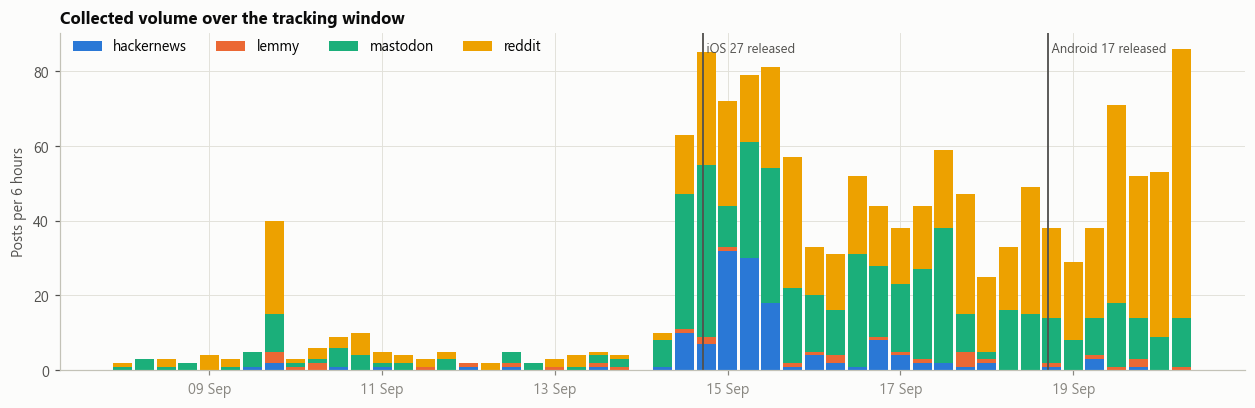

created_utc,2026-09-08 00:00:00+00:00,2026-09-09 00:00:00+00:00,2026-09-10 00:00:00+00:00,2026-09-11 00:00:00+00:00,2026-09-12 00:00:00+00:00,2026-09-13 00:00:00+00:00,2026-09-14 00:00:00+00:00,2026-09-15 00:00:00+00:00,2026-09-16 00:00:00+00:00,2026-09-17 00:00:00+00:00,2026-09-18 00:00:00+00:00,2026-09-19 00:00:00+00:00,2026-09-20 00:00:00+00:00
posts per day,10,52,28,17,11,16,158,289,160,188,145,190,139


In [4]:
hourly = work.set_index("created_utc").resample("1h").size().rename("posts").to_frame()
daily = work.set_index("created_utc").resample("1D").size()
fig, ax = plt.subplots(figsize=(11.5, 3.8))
pivot = work.pivot_table(index=pd.Grouper(key="created_utc", freq="6h"), columns="source", values="post_id", aggfunc="count").fillna(0)
bottom = np.zeros(len(pivot))
for src, c in zip(pivot.columns, SLOTS):
    ax.bar(pivot.index, pivot[src], width=0.22, bottom=bottom, color=c, label=src)
    bottom += pivot[src].values
for label, ts in LAUNCH.items():
    if pivot.index.min() <= ts <= pivot.index.max():
        ax.axvline(ts, color=INK2, lw=1.2)
        ax.text(ts, ax.get_ylim()[1] * 0.97, f" {label} released", fontsize=8.5, color=INK2, va="top")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.set_ylabel("Posts per 6 hours"); ax.set_title("Collected volume over the tracking window")
ax.legend(ncol=4, loc="upper left", bbox_to_anchor=(0, 1.02))
fig.tight_layout()
save(fig, "volume_timeline")
display(daily.rename("posts per day").to_frame().T)

## 3. Applying the Round 2 NLP model

The saved Round 2 artefact is loaded exactly as trained: a weighted ensemble of TF-IDF logistic regression, MiniLM sentence embeddings + logistic regression, and three fine-tuned MiniLM seeds.

One compatibility fix is needed: the pickles were written by a newer scikit-learn than the one installed here, which no longer sets `multi_class` on `LogisticRegression`. The attribute is restored to the value the model was trained with (`multinomial`) rather than retraining, so the Round 2 model is used unchanged.

### Scoring configuration: truncation and the neutral bias

Two details of the saved Round 2 model matter here, and both are handled explicitly.

**Truncation.** The fine-tuned MiniLM component was trained on tweets with `max_len = 50` tokens. The posts collected here are longer (median 74 tokens; 68% exceed 50), so a plain call would score only the opening of two thirds of the corpus. Long posts are therefore split into overlapping word windows, scored separately, and their probabilities averaged. The TF-IDF and embedding components see the full text as before.

**Neutral bias.** The Round 2 artefact carries a validation-selected bias of 1.05 on the Neutral class. The saved `predict()` applies it, while `predict_proba()` does not, so calling `predict_proba` and taking the argmax would silently use a different operating point than Round 2 chose. The bias is applied here.

Neither choice is assumed to help: section 3.2 measures both against 150 hand-labelled in-domain posts.

In [5]:
from sklearn.linear_model import LogisticRegression

def patch_sklearn_compat(obj):
    cand = []
    if hasattr(obj, "steps"):
        cand.append(obj.steps[-1][1])
    elif isinstance(obj, tuple):
        cand.append(obj[1])
    elif isinstance(obj, LogisticRegression):
        cand.append(obj)
    for c in cand:
        if isinstance(c, LogisticRegression) and not hasattr(c, "multi_class"):
            c.multi_class = "multinomial"

engine = nu.SentimentEnsemble(R2 / "model")
for comp in engine.cfg["components"]:
    patch_sklearn_compat(engine._load(comp))
print(json.dumps({k: engine.cfg[k] for k in ["selected_model", "validation_macro_f1", "test_macro_f1"]}, indent=2))
print("components:", [(c["name"], c["weight"]) for c in engine.cfg["components"]], "| neutral bias:", engine.neutral_bias)

def chunk_text(text, words_per_chunk=34, stride=28, max_chunks=8):
    w = str(text).split()
    if len(w) <= words_per_chunk:
        return [str(text)]
    chunks = [" ".join(w[i:i + words_per_chunk]) for i in range(0, len(w), stride)]
    return chunks[:max_chunks] or [str(text)]

def score(texts, chunked=True, bias=True, batch=512):
    # Reproduces the Round 2 ensemble; optionally averages transformer probabilities over chunks
    texts = [str(t) for t in texts]
    lower, cased = nu.clean_series(texts), nu.clean_series_cased(texts)
    total, wsum = np.zeros((len(texts), len(engine.labels))), 0.0
    for comp in engine.cfg["components"]:
        w = comp["weight"]
        if w <= 0:
            continue
        obj = engine._load(comp)
        if comp["kind"] == "sklearn":
            p = np.vstack([obj.predict_proba(texts[i:i + batch]) for i in range(0, len(texts), batch)])
        elif comp["kind"] == "embedding":
            st, clf = obj
            p = clf.predict_proba(st.encode(lower, batch_size=256, normalize_embeddings=True, show_progress_bar=False))
        else:
            src = cased if comp["cased"] else lower
            if not chunked:
                p = np.mean([nu.transformer_proba(m, tk, src, comp["max_len"]) for m, tk in obj], axis=0)
            else:
                pieces, owner = [], []
                for idx, t in enumerate(src):
                    for ch in chunk_text(t):
                        pieces.append(ch)
                        owner.append(idx)
                owner = np.array(owner)
                flat = np.mean([nu.transformer_proba(m, tk, pieces, comp["max_len"]) for m, tk in obj], axis=0)
                p = np.vstack([flat[owner == i].mean(axis=0) for i in range(len(texts))])
        total += w * p
        wsum += w
    proba = total / wsum
    return engine._apply_neutral_bias(proba) if bias else proba

`torch_dtype` is deprecated! Use `dtype` instead!


{
  "selected_model": "Weighted ensemble",
  "validation_macro_f1": 0.7113,
  "test_macro_f1": 0.7227
}
components: [('tfidf_logreg', 0.25), ('embedding_logreg', 0.2), ('minilm_finetuned', 0.55)] | neutral bias: 1.05


In [6]:
if SCORED.exists() and not RESCORE and len(pd.read_csv(SCORED)) == len(work):
    scored = pd.read_csv(SCORED)
    scored["created_utc"] = pd.to_datetime(scored.created_utc, format="mixed", utc=True)
    print("loaded cached scores")
else:
    t0 = time.perf_counter()
    probs = score(work.text_full.tolist(), chunked=True, bias=True)
    scored = work.copy()
    for i, lab in enumerate(engine.labels):
        scored[f"p_{lab.lower()}"] = probs[:, i].round(4)
    scored["sentiment"] = np.array(engine.labels)[probs.argmax(1)]
    scored["confidence"] = probs.max(1).round(4)
    scored.to_csv(SCORED, index=False)
    print(f"scored {len(scored):,} posts in {time.perf_counter()-t0:.0f}s "
          f"({1000*(time.perf_counter()-t0)/len(scored):.1f} ms/post)")
scored["sentiment_score"] = scored.p_positive - scored.p_negative
dist = scored.sentiment.value_counts(normalize=True).reindex(engine.labels)
METRICS["sentiment_distribution"] = dist.round(4).to_dict()
METRICS["confidence"] = {"mean": round(float(scored.confidence.mean()), 4),
                         "share_above_0.7": round(float((scored.confidence > 0.7).mean()), 4)}
print(dist.round(3).to_string()); print(METRICS["confidence"])

loaded cached scores
sentiment
Negative    0.401
Neutral     0.409
Positive    0.190
{'mean': 0.5695, 'share_above_0.7': 0.149}


### 3.2 How accurate is the model on *this* data?

Round 2 reported macro-F1 0.723, but that was on labelled tweets. This section measures the model where it is actually used. 150 posts were drawn at random (not stratified by prediction, which would bias the estimate) and labelled by hand against a fixed rubric: **Positive** = approval, praise or a favourable experience; **Negative** = complaint, bug report, criticism or frustration; **Neutral** = factual news, an announcement, or a question with no clear valence. All three scoring configurations are compared on the same posts.

In [7]:
val = pd.read_csv(OUT / "Entropy_round3_validation_sample.csv")
val = val[val.human_label.notna() & (val.human_label.astype(str) != "")]
configs = {"as-is (truncated, no bias)": dict(chunked=False, bias=False),
           "neutral bias only": dict(chunked=False, bias=True),
           "chunked + neutral bias (used)": dict(chunked=True, bias=True)}
rows, preds = [], {}
for name, kw in configs.items():
    p = score(val.text_full.tolist(), **kw)
    pred = np.array(engine.labels)[p.argmax(1)]
    preds[name] = pred
    rows.append({"configuration": name, "accuracy": accuracy_score(val.human_label, pred),
                 "macro_f1": f1_score(val.human_label, pred, average="macro"),
                 **{f"F1 {l}": v for l, v in zip(engine.labels,
                     f1_score(val.human_label, pred, labels=engine.labels, average=None, zero_division=0))}})
val_res = pd.DataFrame(rows).set_index("configuration")
best = val_res.macro_f1.idxmax()

rng = np.random.default_rng(SEED)
hl, bp = val.human_label.to_numpy(), preds[best]
boot = []
for _ in range(N_BOOT):
    i = rng.integers(0, len(val), len(val))
    boot.append(f1_score(hl[i], bp[i], average="macro", zero_division=0))
ci = np.percentile(boot, [2.5, 97.5])
METRICS["in_domain_validation"] = {
    "n": int(len(val)), "human_label_distribution": val.human_label.value_counts().to_dict(),
    "configurations": val_res.round(4).to_dict("index"), "chosen": best,
    "macro_f1_ci95": [round(float(x), 4) for x in ci],
    "round2_test_macro_f1": engine.cfg["test_macro_f1"],
    "confusion_matrix": confusion_matrix(val.human_label, bp, labels=engine.labels).tolist(),
    "per_class": classification_report(val.human_label, bp, labels=engine.labels, output_dict=True, zero_division=0),
}
display(val_res.round(3))
print(f"chosen: {best} | macro-F1 95% CI [{ci[0]:.3f}, {ci[1]:.3f}] vs {engine.cfg['test_macro_f1']} on Round 2 tweets")
print(classification_report(val.human_label, bp, labels=engine.labels, digits=3, zero_division=0))
display(pd.DataFrame(confusion_matrix(val.human_label, bp, labels=engine.labels),
                     index=[f"true {l}" for l in engine.labels], columns=[f"pred {l}" for l in engine.labels]))

,accuracy,macro_f1,F1 Negative,F1 Neutral,F1 Positive
configuration,,,,,
"as-is (truncated, no bias)",0.653,0.632,0.752,0.600,0.545
neutral bias only,0.673,0.653,0.758,0.634,0.566
chunked + neutral bias (used),0.687,0.666,0.752,0.656,0.591


chosen: chunked + neutral bias (used) | macro-F1 95% CI [0.578, 0.745] vs 0.7227 on Round 2 tweets
              precision    recall  f1-score   support

    Negative      0.855     0.671     0.752        70
     Neutral      0.652     0.662     0.656        65
    Positive      0.448     0.867     0.591        15

    accuracy                          0.687       150
   macro avg      0.651     0.733     0.666       150
weighted avg      0.726     0.687     0.695       150



,pred Negative,pred Neutral,pred Positive
true Negative,47,21,2
true Neutral,8,43,14
true Positive,0,2,13


In [8]:
# How much does chunking change the corpus-level picture?
sample_n = min(400, len(work))
sub = work.sample(sample_n, random_state=SEED)
p_trunc = score(sub.text_full.tolist(), chunked=False, bias=True)
p_chunk = score(sub.text_full.tolist(), chunked=True, bias=True)
lab_t = np.array(engine.labels)[p_trunc.argmax(1)]
lab_c = np.array(engine.labels)[p_chunk.argmax(1)]
changed = float((lab_t != lab_c).mean())
net = lambda lab: (lab == "Positive").mean() - (lab == "Negative").mean()
METRICS["chunking_effect"] = {"n_sample": int(sample_n), "labels_changed_share": round(changed, 4),
                              "net_truncated": round(float(net(lab_t)), 4), "net_chunked": round(float(net(lab_c)), 4)}
print(f"On {sample_n} posts, chunking changes {changed:.1%} of labels; "
      f"net sentiment {net(lab_t):+.3f} (truncated) vs {net(lab_c):+.3f} (chunked)")

On 400 posts, chunking changes 12.0% of labels; net sentiment -0.185 (truncated) vs -0.198 (chunked)


In [9]:
display(scored[["created_utc", "source", "sentiment", "confidence", "text_full"]].head(6))

,created_utc,source,sentiment,confidence,text_full
0,2026-09-08 03:48:27+00:00,reddit,Negative,0.5295,Suddenly videos stored on my phone won't play ...
1,2026-09-08 05:32:08+00:00,mastodon,Positive,0.5045,One UI 9.0 Beta 2 is now live for the Galaxy S...
2,2026-09-08 08:39:22+00:00,mastodon,Positive,0.5961,Sony Xperia 1 VIII Android 17 Update: What’s N...
3,2026-09-08 08:39:22.135000+00:00,mastodon,Positive,0.5961,Sony Xperia 1 VIII Android 17 Update: What’s N...
4,2026-09-08 10:53:05.049000+00:00,mastodon,Neutral,0.6490,Sony hat das Update auf Android 17 für einige ...
5,2026-09-08 12:20:07+00:00,reddit,Neutral,0.5007,Camera app in iOS 27 reportedly includes four ...


## 4. Sentiment analysis and sentiment shifts

Opinion is tracked with a **net sentiment index** = share(Positive) - share(Negative) inside each 6-hour bin. A shift is only reported when the change between two consecutive bins is statistically significant: a two-proportion z-test on the positive share and on the negative share, with Holm correction across all bin boundaries tested.

In [10]:
BIN = "12h"
g = scored.set_index("created_utc").resample(BIN)
bins = pd.DataFrame({"n": g.size(),
                     "pos": g.apply(lambda d: (d.sentiment == "Positive").sum() if len(d) else 0),
                     "neg": g.apply(lambda d: (d.sentiment == "Negative").sum() if len(d) else 0),
                     "neu": g.apply(lambda d: (d.sentiment == "Neutral").sum() if len(d) else 0)})
bins = bins[bins.n >= 40]
bins["pos_share"] = bins.pos / bins.n
bins["neg_share"] = bins.neg / bins.n
bins["net"] = bins.pos_share - bins.neg_share

def two_prop(c1, n1, c2, n2):
    p = (c1 + c2) / (n1 + n2)
    se = np.sqrt(p * (1 - p) * (1 / n1 + 1 / n2))
    if se == 0:
        return 0.0, 1.0
    z = (c2 / n2 - c1 / n1) / se
    return z, 2 * (1 - stats.norm.cdf(abs(z)))

tests = []
idx = bins.index
for a, b in zip(idx[:-1], idx[1:]):
    r1, r2 = bins.loc[a], bins.loc[b]
    z_pos, p_pos = two_prop(r1.pos, r1.n, r2.pos, r2.n)
    z_neg, p_neg = two_prop(r1.neg, r1.n, r2.neg, r2.n)
    tests.append({"from": a, "to": b, "n_before": int(r1.n), "n_after": int(r2.n),
                  "net_before": r1.net, "net_after": r2.net, "delta_net": r2.net - r1.net,
                  "p_pos": p_pos, "p_neg": p_neg, "p_min": min(p_pos, p_neg)})
shifts = pd.DataFrame(tests)
m = len(shifts)
order = shifts.p_min.rank(method="first").astype(int)
shifts["p_holm"] = np.minimum(1, shifts.p_min * (m - order + 1))
shifts = shifts.sort_values("p_holm")
SIG = shifts[shifts.p_holm < 0.05]
METRICS["sentiment_shifts"] = shifts.head(6).assign(**{c: shifts[c].astype(str) for c in ["from", "to"]}).round(4).to_dict("records")
print(f"{len(SIG)} significant shifts (Holm-corrected p < 0.05) out of {m} consecutive-bin boundaries")
display(shifts.head(6).round(4))

# Pre-specified windows: only three comparisons, so the correction is far less punishing
# than scanning every boundary, and each one answers a question set before seeing the data.
L = LAUNCH["iOS 27"]
periods = {
    "Pre-launch (8-14 Sep)": (scored.created_utc < L),
    "Launch +0-24h": (scored.created_utc >= L) & (scored.created_utc < L + pd.Timedelta("24h")),
    "Settling +24-72h": (scored.created_utc >= L + pd.Timedelta("24h")) & (scored.created_utc < L + pd.Timedelta("72h")),
    "Later (72h+)": (scored.created_utc >= L + pd.Timedelta("72h")),
}
per = pd.DataFrame([{"period": k, "n": int(v.sum()),
                     "pos": (scored.sentiment[v] == "Positive").mean(),
                     "neg": (scored.sentiment[v] == "Negative").mean()} for k, v in periods.items()])
per["net"] = per.pos - per.neg
prespec = []
for a, b in [(0, 1), (1, 2), (2, 3)]:
    ra, rb = per.iloc[a], per.iloc[b]
    z_pos, p_pos = two_prop(round(ra.pos * ra.n), ra.n, round(rb.pos * rb.n), rb.n)
    z_neg, p_neg = two_prop(round(ra.neg * ra.n), ra.n, round(rb.neg * rb.n), rb.n)
    prespec.append({"comparison": f"{ra.period} -> {rb.period}", "n_before": int(ra.n), "n_after": int(rb.n),
                    "net_before": ra.net, "net_after": rb.net, "delta_net": rb.net - ra.net,
                    "p_pos": p_pos, "p_neg": p_neg, "p_min": min(p_pos, p_neg)})
prespec = pd.DataFrame(prespec)
rank = prespec.p_min.rank(method="first").astype(int)
prespec["p_holm"] = np.minimum(1, prespec.p_min * (len(prespec) - rank + 1))
METRICS["period_sentiment"] = per.round(4).to_dict("records")
METRICS["prespecified_shifts"] = prespec.round(5).to_dict("records")
display(per.round(3)); display(prespec.round(4))

1 significant shifts (Holm-corrected p < 0.05) out of 12 consecutive-bin boundaries


,from,to,n_before,n_after,net_before,net_after,delta_net,p_pos,p_neg,p_min,p_holm
1,2026-09-14 12:00:00+00:00,2026-09-15 00:00:00+00:00,148,151,0.1554,-0.2583,-0.4137,0.0043,0.0000,0.0000,0.0000
6,2026-09-17 00:00:00+00:00,2026-09-17 12:00:00+00:00,82,106,-0.0854,-0.3113,-0.2260,0.0183,0.2641,0.0183,0.2016
3,2026-09-15 12:00:00+00:00,2026-09-16 00:00:00+00:00,138,64,-0.3261,-0.0938,0.2323,0.1627,0.0474,0.0474,0.4744
10,2026-09-19 00:00:00+00:00,2026-09-19 12:00:00+00:00,67,123,-0.4030,-0.3821,0.0209,0.5106,0.5030,0.5030,0.5030
5,2026-09-16 12:00:00+00:00,2026-09-17 00:00:00+00:00,96,82,-0.1667,-0.0854,0.0813,0.0682,0.6194,0.0682,0.6139
11,2026-09-19 12:00:00+00:00,2026-09-20 00:00:00+00:00,123,139,-0.3821,-0.2158,0.1663,0.0937,0.1107,0.0937,0.7498


,period,n,pos,neg,net
0,Pre-launch (8-14 Sep),171,0.251,0.199,0.053
1,Launch +0-24h,330,0.245,0.367,-0.121
2,Settling +24-72h,355,0.228,0.397,-0.169
3,Later (72h+),547,0.113,0.486,-0.373


,comparison,n_before,n_after,net_before,net_after,delta_net,p_pos,p_neg,p_min,p_holm
0,Pre-launch (8-14 Sep) -> Launch +0-24h,171,330,0.0526,-0.1212,-0.1738,0.8826,0.0001,0.0001,0.0002
1,Launch +0-24h -> Settling +24-72h,330,355,-0.1212,-0.1690,-0.0478,0.5947,0.4116,0.4116,0.4116
2,Settling +24-72h -> Later (72h+),355,547,-0.1690,-0.3729,-0.2039,0.0000,0.0086,0.0000,0.0000


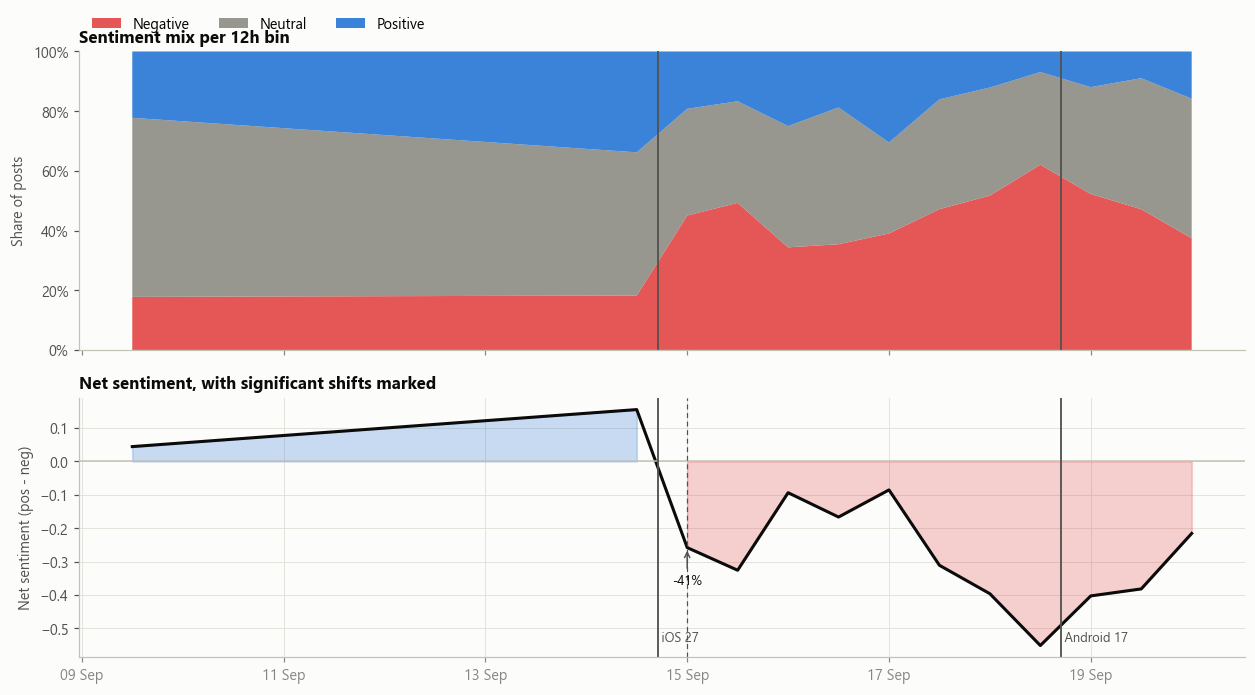

In [11]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11.5, 6.4), sharex=True, gridspec_kw={"height_ratios": [1.15, 1]})
share = bins[["neg", "neu", "pos"]].div(bins.n, axis=0)
a1.stackplot(bins.index, share.neg, share.neu, share.pos,
             colors=[SENT["Negative"], SENT["Neutral"], SENT["Positive"]],
             labels=["Negative", "Neutral", "Positive"], alpha=0.92)
a1.set_ylim(0, 1); a1.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
a1.set_ylabel("Share of posts"); a1.set_title(f"Sentiment mix per {BIN} bin")
a1.legend(ncol=3, loc="lower left", bbox_to_anchor=(0, 1.02)); a1.grid(False)

a2.plot(bins.index, bins.net, color=INK, lw=2)
a2.fill_between(bins.index, 0, bins.net, where=bins.net >= 0, color=SENT["Positive"], alpha=0.25)
a2.fill_between(bins.index, 0, bins.net, where=bins.net < 0, color=SENT["Negative"], alpha=0.25)
a2.axhline(0, color=BASE, lw=1)
for _, r in SIG.head(4).iterrows():
    a2.annotate(f"{r.delta_net:+.0%}", xy=(r["to"], bins.loc[r["to"], "net"]), xytext=(0, 18 if r.delta_net > 0 else -24),
                textcoords="offset points", ha="center", fontsize=8.5, color=INK,
                arrowprops=dict(arrowstyle="->", color=INK2, lw=1))
    a2.axvline(r["to"], color=INK2, lw=0.8, ls=(0, (4, 3)))
for label, ts in LAUNCH.items():
    if bins.index.min() <= ts <= bins.index.max():
        for ax in (a1, a2):
            ax.axvline(ts, color=INK2, lw=1.2)
        a2.text(ts, a2.get_ylim()[0] * 0.92, f" {label}", fontsize=8.5, color=INK2)
a2.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
a2.set_ylabel("Net sentiment (pos - neg)"); a2.set_title("Net sentiment, with significant shifts marked")
fig.tight_layout()
save(fig, "sentiment_timeline")

### Is the decline real, or just a change in which platforms we sampled?

Reddit is the most negative platform here and its share of the data grows over the window, so the
overall decline could in principle be a sampling artefact. The check below holds the platform fixed.

In [12]:
comp = pd.crosstab(pd.cut(scored.created_utc,
                          [scored.created_utc.min() - pd.Timedelta("1h"), L, L + pd.Timedelta("24h"),
                           L + pd.Timedelta("72h"), scored.created_utc.max() + pd.Timedelta("1h")],
                          labels=list(periods)), scored.source, normalize="index")
scored["period"] = pd.cut(scored.created_utc,
                          [scored.created_utc.min() - pd.Timedelta("1h"), L, L + pd.Timedelta("24h"),
                           L + pd.Timedelta("72h"), scored.created_utc.max() + pd.Timedelta("1h")],
                          labels=list(periods))
net = lambda g: (g.sentiment == "Positive").mean() - (g.sentiment == "Negative").mean()
within = (scored.groupby(["source", "period"], observed=True)
          .apply(lambda g: pd.Series({"n": len(g), "net": net(g)}), include_groups=False)
          .reset_index().pivot(index="source", columns="period", values=["n", "net"]))
print("Platform mix per period (share of posts):"); display(comp.round(3))
print("Net sentiment within each platform:"); display(within.round(3))

# Formal check on the platform with good coverage in both the first and last period
mas = scored[scored.source == "mastodon"]
pre_m, late_m = mas[mas.period == "Pre-launch (8-14 Sep)"], mas[mas.period == "Later (72h+)"]
z_p, p_p = two_prop((pre_m.sentiment == "Positive").sum(), len(pre_m), (late_m.sentiment == "Positive").sum(), len(late_m))
z_n, p_n = two_prop((pre_m.sentiment == "Negative").sum(), len(pre_m), (late_m.sentiment == "Negative").sum(), len(late_m))
METRICS["composition"] = {"platform_mix": comp.round(4).to_dict(),
                          "within_source_net": within["net"].round(4).to_dict(),
                          "mastodon_only": {"n_pre": int(len(pre_m)), "n_late": int(len(late_m)),
                                            "net_pre": round(float(net(pre_m)), 4), "net_late": round(float(net(late_m)), 4),
                                            "positive_z": round(float(z_p), 3), "positive_p": float(p_p),
                                            "negative_z": round(float(z_n), 3), "negative_p": float(p_n)}}
print(f"Mastodon only: net {net(pre_m):+.2f} (n={len(pre_m)}) -> {net(late_m):+.2f} (n={len(late_m)}); "
      f"positive share p = {p_p:.2g}, negative share p = {p_n:.2g}")

Platform mix per period (share of posts):


source,hackernews,lemmy,mastodon,reddit
created_utc,,,,
Pre-launch (8-14 Sep),0.076,0.076,0.409,0.439
Launch +0-24h,0.276,0.009,0.415,0.300
Settling +24-72h,0.073,0.020,0.451,0.456
Later (72h+),0.015,0.020,0.267,0.698


Net sentiment within each platform:


n                                              \
period     Pre-launch (8-14 Sep) Launch +0-24h Settling +24-72h Later (72h+)   
source                                                                         
hackernews                  13.0          91.0             26.0          8.0   
lemmy                       13.0           3.0              7.0         11.0   
mastodon                    70.0         137.0            160.0        146.0   
reddit                      75.0          99.0            162.0        382.0   

                             net                                              
period     Pre-launch (8-14 Sep) Launch +0-24h Settling +24-72h Later (72h+)  
source                                                                        
hackernews                -0.154        -0.352           -0.269       -0.375  
lemmy                     -0.154        -0.333           -0.286       -0.545  
mastodon                   0.429         0.146            0.175       -0.171  
reddit                    -0.227        -0.273           -0.488       -0.445

Mastodon only: net +0.43 (n=70) -> -0.17 (n=146); positive share p = 0.00021, negative share p = 3.6e-08


## 5. Activity analysis and engagement spikes

Two different things can spike: **how much** people post, and **how hard the platform reacts** to what they post. Volume spikes use a robust z-score of hourly counts against a trailing 24-hour median and MAD. Engagement spikes use the same detector on total engagement per bin (Hacker News points, Mastodon favourites + boosts, Lemmy score; Reddit's RSS feed does not expose scores).

In [13]:
# Robust z-score against a trailing baseline. When the median absolute deviation is zero
# (a long run of quiet hours), fall back to a trailing standard deviation.
def robust_z(series, window=48, min_periods=12):
    med = series.rolling(window, min_periods=min_periods).median().shift(1)
    mad = (series - med).abs().rolling(window, min_periods=min_periods).median().shift(1)
    scale = 1.4826 * mad
    fallback = series.rolling(window, min_periods=min_periods).std().shift(1)
    scale = scale.where(scale > 0, fallback)
    scale = scale.where(scale > 0, np.nan)
    return (series - med) / scale

vol = scored.set_index("created_utc").resample("1h").size().rename("posts").to_frame()
eng_src = scored[scored.source.isin(["hackernews", "mastodon", "lemmy"])]
vol["engagement"] = eng_src.set_index("created_utc").score.resample("1h").sum().reindex(vol.index).fillna(0)
vol["z_posts"] = robust_z(vol.posts)
vol["z_engagement"] = robust_z(vol.engagement)
spikes = vol[((vol.z_posts > 3) & (vol.posts >= 6)) | ((vol.z_engagement > 3) & (vol.engagement >= 30))].copy()
spikes["type"] = np.where(spikes.z_posts > 3, np.where(spikes.z_engagement > 3, "volume + engagement", "volume"), "engagement")
METRICS["spikes"] = [{"hour": str(i), "posts": int(r.posts), "engagement": float(r.engagement),
                      "z_posts": round(float(r.z_posts), 2) if pd.notna(r.z_posts) else None,
                      "z_engagement": round(float(r.z_engagement), 2) if pd.notna(r.z_engagement) else None,
                      "type": r.type} for i, r in spikes.iterrows()]
print(f"{len(spikes)} spike hours detected (robust z > 3)")
display(spikes[["posts", "engagement", "z_posts", "z_engagement", "type"]].round(2))

44 spike hours detected (robust z > 3)


,posts,engagement,z_posts,z_engagement,type
created_utc,,,,,
2026-09-09 18:00:00+00:00,14,16.0,14.89,13.07,volume + engagement
2026-09-09 19:00:00+00:00,10,6.0,4.31,2.18,volume
2026-09-10 09:00:00+00:00,2,53.0,0.74,17.69,engagement
2026-09-13 00:00:00+00:00,1,68.0,0.67,21.19,engagement
2026-09-13 12:00:00+00:00,4,76.0,3.60,7.73,volume + engagement
2026-09-14 13:00:00+00:00,10,33.0,26.98,2.27,volume
2026-09-14 17:00:00+00:00,36,851.0,97.13,56.03,volume + engagement
2026-09-14 18:00:00+00:00,22,14.0,59.36,0.11,volume
2026-09-14 19:00:00+00:00,22,71.0,59.36,0.58,volume


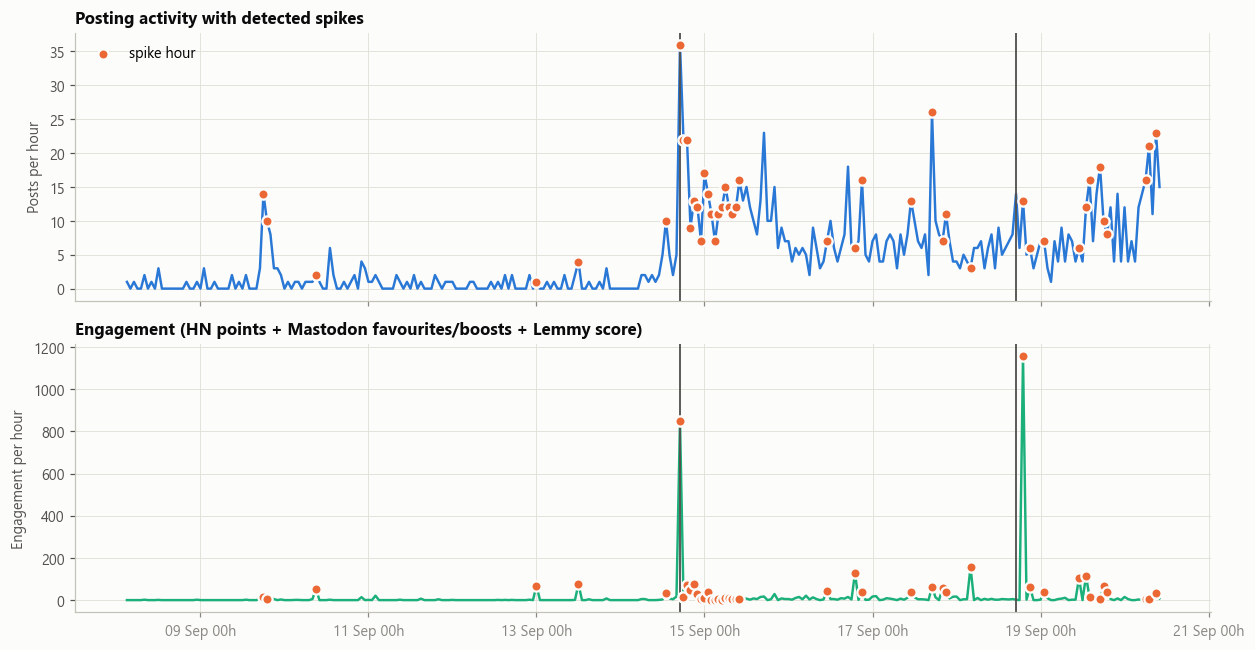

In [14]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11.5, 6), sharex=True)
a1.plot(vol.index, vol.posts, color=S1, lw=1.6)
a1.scatter(spikes.index, spikes.posts, s=45, color=S2, edgecolor=SURF, linewidth=1.5, zorder=3, label="spike hour")
a1.set_ylabel("Posts per hour"); a1.set_title("Posting activity with detected spikes"); a1.legend(loc="upper left")
a2.plot(vol.index, vol.engagement, color=SLOTS[2], lw=1.6)
a2.scatter(spikes.index, spikes.engagement, s=45, color=S2, edgecolor=SURF, linewidth=1.5, zorder=3)
a2.set_ylabel("Engagement per hour"); a2.set_title("Engagement (HN points + Mastodon favourites/boosts + Lemmy score)")
for ax in (a1, a2):
    for label, ts in LAUNCH.items():
        if vol.index.min() <= ts <= vol.index.max():
            ax.axvline(ts, color=INK2, lw=1.2)
a2.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Hh"))
fig.tight_layout()
save(fig, "activity_spikes")

Sentiment differs by platform: chi2 = 153.4, p = 1.5e-30


,posts,authors,pos,neg,mean_conf,net
source,,,,,,
hackernews,138,120,0.138,0.457,0.565,-0.319
lemmy,34,31,0.059,0.382,0.574,-0.324
mastodon,513,318,0.335,0.232,0.594,0.103
reddit,718,663,0.103,0.511,0.552,-0.408


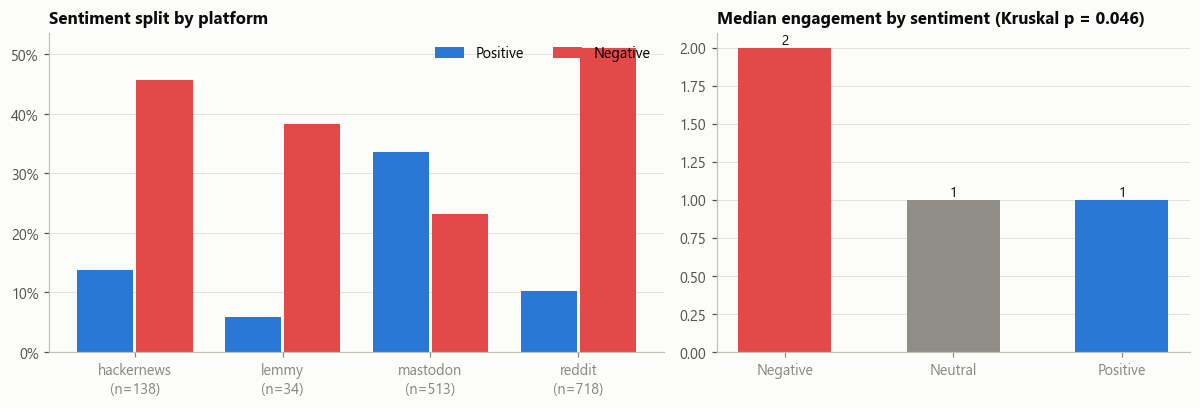

In [15]:
by_src = (scored.groupby("source")
          .agg(posts=("post_id", "size"), authors=("author_hash", "nunique"),
               pos=("sentiment", lambda s: (s == "Positive").mean()),
               neg=("sentiment", lambda s: (s == "Negative").mean()),
               mean_conf=("confidence", "mean")))
by_src["net"] = by_src.pos - by_src.neg
chi = stats.chi2_contingency(pd.crosstab(scored.source, scored.sentiment))
METRICS["by_source"] = by_src.round(4).to_dict("index")
METRICS["source_sentiment_chi2"] = {"chi2": round(float(chi.statistic), 2), "p": float(chi.pvalue), "dof": int(chi.dof)}
print(f"Sentiment differs by platform: chi2 = {chi.statistic:.1f}, p = {chi.pvalue:.2g}")
display(by_src.round(3))

eng = scored[scored.source.isin(["hackernews", "mastodon", "lemmy"]) & scored.score.notna()]
med = eng.groupby("sentiment").score.median().reindex(engine.labels)
kw = stats.kruskal(*[g.score.values for _, g in eng.groupby("sentiment")])
METRICS["engagement_by_sentiment"] = {"median": med.round(2).to_dict(), "kruskal_p": float(kw.pvalue),
                                      "n": int(len(eng))}
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1.3, 1]})
x = np.arange(len(by_src))
a1.bar(x - 0.2, by_src.pos, 0.38, color=SENT["Positive"], label="Positive")
a1.bar(x + 0.2, by_src.neg, 0.38, color=SENT["Negative"], label="Negative")
a1.set_xticks(x, [f"{s}\n(n={int(by_src.loc[s, 'posts'])})" for s in by_src.index])
a1.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
a1.set_title("Sentiment split by platform"); a1.legend(ncol=2, loc="upper right"); a1.grid(axis="x", visible=False)
a2.bar(med.index, med.values, color=[SENT[s] for s in med.index], width=0.55)
for i, v in enumerate(med.values):
    a2.text(i, v, f"{v:.0f}", ha="center", va="bottom", fontsize=9, color=INK)
a2.set_title(f"Median engagement by sentiment (Kruskal p = {kw.pvalue:.3f})"); a2.grid(axis="x", visible=False)
fig.tight_layout()
save(fig, "platform_engagement")

## 6. Topic and entity analysis

Three views: which named entities are discussed, which words separate positive from negative reaction (log-odds ratio with an informative Dirichlet prior, Monroe et al. 2008), and unsupervised themes from NMF.

,entity,mentions,authors,pos,neg,net,median_engagement
7,bugs/crashes,181,169,0.072,0.746,-0.674,1.0
10,notifications,54,48,0.019,0.630,-0.611,7.5
8,privacy,50,50,0.120,0.540,-0.420,2.0
12,install/update process,149,138,0.174,0.477,-0.302,1.0
11,Siri/assistant,279,246,0.129,0.401,-0.272,1.0
6,performance,115,106,0.304,0.557,-0.252,1.0
2,macOS 27,378,318,0.233,0.458,-0.225,1.0
3,Apple Intelligence,344,293,0.157,0.378,-0.221,1.0
4,Android 17,127,104,0.118,0.307,-0.189,1.0
0,iOS 27,784,650,0.207,0.370,-0.163,1.0


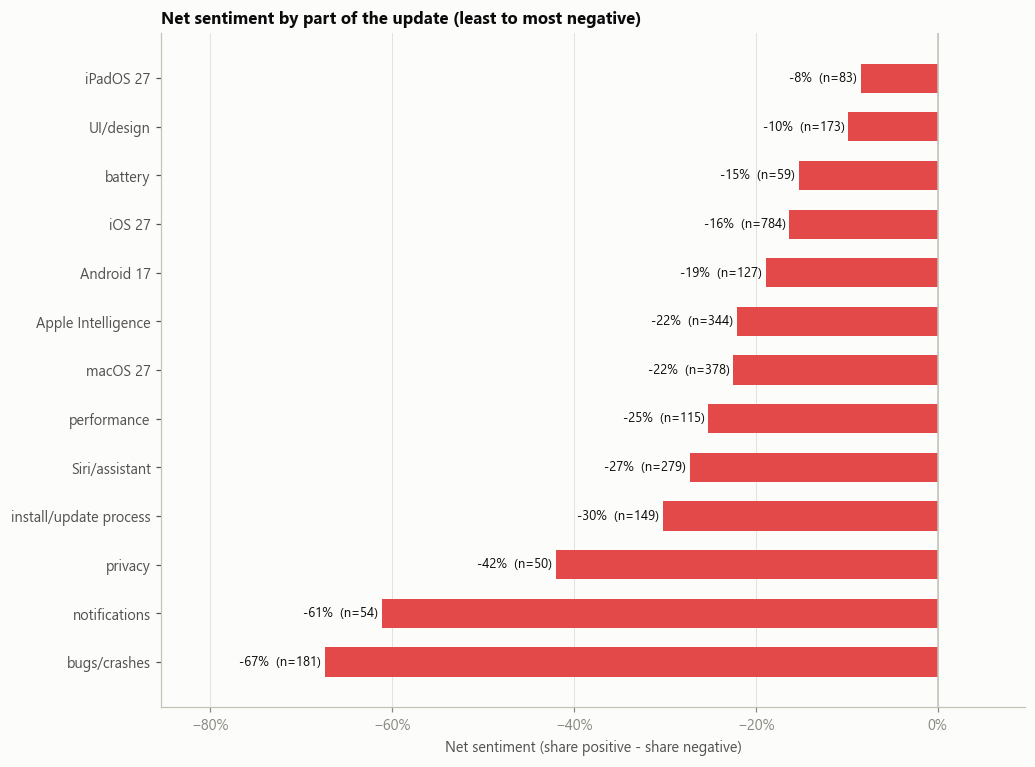

In [16]:
ent_rows = []
for name in ENTITIES:
    sub = scored[scored[name]]
    if len(sub) >= 25:
        ent_rows.append({"entity": name, "mentions": len(sub), "authors": sub.author_hash.nunique(),
                         "pos": (sub.sentiment == "Positive").mean(), "neg": (sub.sentiment == "Negative").mean(),
                         "net": (sub.sentiment == "Positive").mean() - (sub.sentiment == "Negative").mean(),
                         "median_engagement": sub[sub.score.notna()].score.median()})
FEATURES = {"battery": r"\bbattery|\bdrain", "performance": r"\bslow|\blag|\bperformance|\bfast\b|\bsnappy",
            "bugs/crashes": r"\bbug|\bcrash|\bbroke|\bglitch", "privacy": r"\bprivacy|\btrack|\bdata collection",
            "UI/design": r"\bui\b|\bdesign|\bicon|\bhome screen|\bliquid glass", "battery life after update": r"battery life",
            "notifications": r"\bnotification", "Siri/assistant": r"\bsiri\b|assistant",
            "install/update process": r"\binstall|\bdownload|\bupdate failed|\brollback|\bdowngrade"}
for name, pat in FEATURES.items():
    sub = scored[scored.text_full.str.lower().str.contains(pat, regex=True, na=False)]
    if len(sub) >= 25:
        ent_rows.append({"entity": name, "mentions": len(sub), "authors": sub.author_hash.nunique(),
                         "pos": (sub.sentiment == "Positive").mean(), "neg": (sub.sentiment == "Negative").mean(),
                         "net": (sub.sentiment == "Positive").mean() - (sub.sentiment == "Negative").mean(),
                         "median_engagement": sub[sub.score.notna()].score.median()})
ents = pd.DataFrame(ent_rows).sort_values("net")
METRICS["entities"] = ents.round(4).to_dict("records")
display(ents.round(3))

fig, ax = plt.subplots(figsize=(9.5, 0.42 * len(ents) + 1.6))
y = np.arange(len(ents))
ax.barh(y, ents.net, color=[SENT["Negative"] if v < 0 else SENT["Positive"] for v in ents.net], height=0.6)
for yi, (_, r) in zip(y, ents.iterrows()):
    off = 0.004 if r.net >= 0 else -0.004
    ax.text(r.net + off, yi, f"{r.net:+.0%}  (n={int(r.mentions)})", va="center",
            ha="left" if r.net >= 0 else "right", fontsize=8.5, color=INK)
ax.set_yticks(y, ents.entity)
ax.axvline(0, color=BASE, lw=1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_xlim(ents.net.min() - 0.18, ents.net.max() + 0.18)
ax.set_xlabel("Net sentiment (share positive - share negative)")
ax.set_title("Net sentiment by part of the update (least to most negative)")
ax.grid(axis="y", visible=False)
fig.tight_layout()
save(fig, "entity_sentiment")

In [17]:
FEED_STOP = ["submitted", "link", "comments", "https", "http", "com", "www", "amp", "reddit", "post", "posted"]
STOPWORDS = list(TfidfVectorizer(stop_words="english").get_stop_words()) + FEED_STOP
cv = CountVectorizer(ngram_range=(1, 2), min_df=8, stop_words=STOPWORDS, max_features=8000)
X = cv.fit_transform(scored.text_full.str.lower())
vocab = np.array(cv.get_feature_names_out())
pos_mask = (scored.sentiment == "Positive").values
neg_mask = (scored.sentiment == "Negative").values
y_pos = np.asarray(X[pos_mask].sum(0)).ravel()
y_neg = np.asarray(X[neg_mask].sum(0)).ravel()
alpha = np.asarray(X.sum(0)).ravel()
a0 = alpha.sum()
def logodds(y_i, y_j):
    n_i, n_j = y_i.sum(), y_j.sum()
    d_i = np.log((y_i + alpha) / (n_i + a0 - y_i - alpha))
    d_j = np.log((y_j + alpha) / (n_j + a0 - y_j - alpha))
    var = 1 / (y_i + alpha) + 1 / (y_j + alpha)
    return (d_i - d_j) / np.sqrt(var)
z = logodds(y_pos, y_neg)
top_pos = vocab[np.argsort(-z)[:15]]
top_neg = vocab[np.argsort(z)[:15]]
METRICS["log_odds"] = {"positive": list(top_pos), "negative": list(top_neg)}
display(pd.DataFrame({"most positive-leaning": top_pos, "most negative-leaning": top_neg}))

tf = TfidfVectorizer(max_features=6000, min_df=8, stop_words=STOPWORDS, ngram_range=(1, 2))
V = tf.fit_transform(scored.text_full.str.lower())
nmf = NMF(n_components=6, random_state=42, init="nndsvda", max_iter=400).fit(V)
terms = np.array(tf.get_feature_names_out())
W = nmf.transform(V)
scored["nmf_topic"] = W.argmax(1)
topics = []
for k in range(nmf.n_components):
    sub = scored[scored.nmf_topic == k]
    topics.append({"topic": k, "size": len(sub), "share": len(sub) / len(scored),
                   "top_terms": ", ".join(terms[np.argsort(-nmf.components_[k])[:8]]),
                   "net_sentiment": (sub.sentiment == "Positive").mean() - (sub.sentiment == "Negative").mean()})
topics = pd.DataFrame(topics).sort_values("size", ascending=False)
METRICS["nmf_topics"] = topics.round(4).to_dict("records")
display(topics.round(3))

,most positive-leaning,most negative-leaning
0,new,don
1,ios27,storage
2,2026,issue
3,improvements,fix
4,galaxy,tried
5,health,bug
6,new features,problem
7,apple,mac
8,available,external
9,apple app,working


,topic,size,share,top_terms,net_sentiment
0,0,392,0.279,"ios, ios 27, 27, iphone, 26, ios 26, update, beta",-0.311
1,1,299,0.213,"macos, macos 27, 27, golden, golden gate, gate...",-0.284
5,5,233,0.166,"ios27, app, macos27, ios27 macos27, new, apple...",0.129
3,3,207,0.148,"siri, ai, siri ai, new siri, new, just, use, turn",-0.338
2,2,141,0.100,"android, android 17, 17, update, pixel, qpr1, ...",-0.220
4,4,131,0.093,"apple, intelligence, apple intelligence, featu...",-0.130


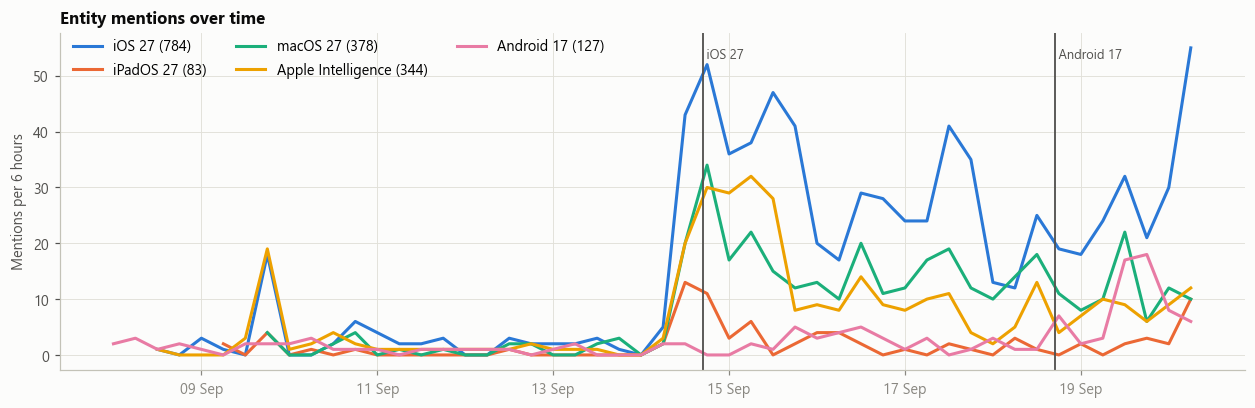

In [18]:
fig, ax = plt.subplots(figsize=(11.5, 3.8))
ent_time = scored.set_index("created_utc")
for name, c in zip(ENTITIES, SLOTS):
    s = ent_time[ent_time[name]].resample("6h").size()
    if s.sum() >= 30:
        ax.plot(s.index, s.values, color=c, lw=2, label=f"{name} ({int(s.sum())})")
for label, ts in LAUNCH.items():
    if ent_time.index.min() <= ts <= ent_time.index.max():
        ax.axvline(ts, color=INK2, lw=1.2)
        ax.text(ts, ax.get_ylim()[1] * 0.95, f" {label}", fontsize=8.5, color=INK2, va="top")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.set_ylabel("Mentions per 6 hours"); ax.set_title("Entity mentions over time")
ax.legend(ncol=3, loc="upper left", bbox_to_anchor=(0, 1.02))
fig.tight_layout()
save(fig, "entity_timeline")

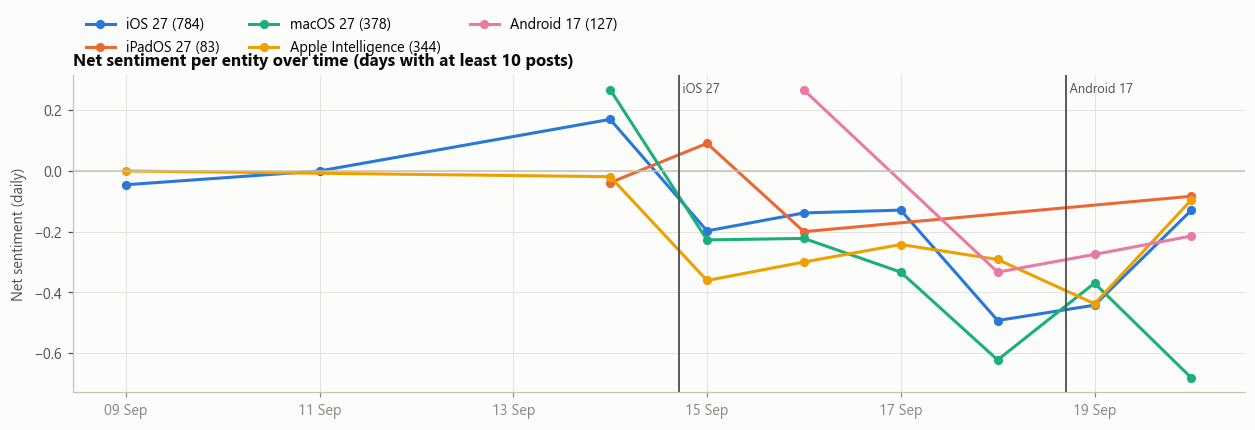

{
 "iOS 27": {
  "2026-09-09": -0.0455,
  "2026-09-11": 0.0,
  "2026-09-14": 0.17,
  "2026-09-15": -0.1975,
  "2026-09-16": -0.1383,
  "2026-09-17": -0.129,
  "2026-09-18": -0.4928,
  "2026-09-19": -0.4421,
  "2026-09-20": -0.1294
 },
 "iPadOS 27": {
  "2026-09-14": -0.0385,
  "2026-09-15": 0.0909,
  "2026-09-16": -0.2,
  "2026-09-20": -0.0833
 },
 "macOS 27": {
  "2026-09-14": 0.2679,
  "2026-09-15": -0.2273,
  "2026-09-16": -0.2222,
  "2026-09-17": -0.3333,
  "2026-09-18": -0.6226,
  "2026-09-19": -0.3696,
  "2026-09-20": -0.6818
 },
 "Apple Intelligence": {
  "2026-09-09": 0.0,
  "2026-09-14": -0.0189,
  "2026-09-15": -0.3608,
  "2026-09-16": -0.3,
  "2026-09-17": -0.2424,
  "2026-09-18": -0.2917,
  "2026-09-19": -0.4375,
  "2026-09-20": -0.0952
 },
 "Android 17": {
  "2026-09-16": 0.2667,
  "2026-09-18": -0.3333,
  "2026-09-19": -0.275,
  "2026-09-20": -0.2143
 }
}


In [19]:
# Sentiment (not just volume) per entity over time
tracked = [e for e in ENTITIES if scored[e].sum() >= 80]
fig, ax = plt.subplots(figsize=(11.5, 4))
for name, c in zip(tracked, SLOTS):
    g = scored[scored[name]].set_index("created_utc").resample("1D")
    n = g.size()
    net = g.sentiment.apply(lambda x: (x == "Positive").mean() - (x == "Negative").mean() if len(x) >= 10 else np.nan)
    keep = n >= 10
    ax.plot(net.index[keep], net[keep], color=c, lw=2, marker="o", ms=5, label=f"{name} ({int(scored[name].sum())})")
ax.axhline(0, color=BASE, lw=1)
for label, ts in LAUNCH.items():
    if scored.created_utc.min() <= ts <= scored.created_utc.max():
        ax.axvline(ts, color=INK2, lw=1.2)
        ax.text(ts, ax.get_ylim()[1] * 0.92, f" {label}", fontsize=8.5, color=INK2, va="top")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.set_ylabel("Net sentiment (daily)")
ax.set_title("Net sentiment per entity over time (days with at least 10 posts)")
ax.legend(ncol=3, loc="lower left", bbox_to_anchor=(0, 1.02))
fig.tight_layout()
save(fig, "entity_sentiment_timeline")

ent_daily = {}
for name in tracked:
    g = scored[scored[name]].set_index("created_utc").resample("1D")
    n, net = g.size(), g.sentiment.apply(lambda x: (x == "Positive").mean() - (x == "Negative").mean() if len(x) >= 10 else np.nan)
    ent_daily[name] = {str(d.date()): round(float(v), 4) for d, v, c in zip(net.index, net, n) if c >= 10 and pd.notna(v)}
METRICS["entity_daily_net"] = ent_daily
print(json.dumps(ent_daily, indent=1)[:900])

## 7. Trigger explanations

Each spike and each significant sentiment shift is matched against two independent sources of evidence: news articles published in the same window (Google News RSS) and the most-engaged posts written inside that window. Nothing is inferred from the model alone.

In [20]:
def window_evidence(ts, hours_before=6, hours_after=6, k=4):
    lo, hi = ts - pd.Timedelta(hours=hours_before), ts + pd.Timedelta(hours=hours_after)
    n = news[(news.published_utc >= lo) & (news.published_utc <= hi)]
    p = scored[(scored.created_utc >= lo) & (scored.created_utc <= hi)]
    top_posts = p.sort_values("score", ascending=False).head(k) if p.score.notna().any() else p.head(k)
    return n.head(k), top_posts

triggers = []
for _, r in spikes.iterrows():
    n, p = window_evidence(r.name)
    triggers.append({"when": str(r.name), "kind": f"{r.type} spike",
                     "size": f"{int(r.posts)} posts/h (z={r.z_posts:.1f})" if pd.notna(r.z_posts) else f"engagement z={r.z_engagement:.1f}",
                     "headlines": list(n.title.head(3)), "top_post": (p.text_full.iloc[0][:180] if len(p) else "")})
for _, r in SIG.head(4).iterrows():
    n, p = window_evidence(r["to"])
    triggers.append({"when": str(r["to"]), "kind": "sentiment shift",
                     "size": f"net {r.net_before:+.0%} -> {r.net_after:+.0%} (Holm p={r.p_holm:.3f})",
                     "headlines": list(n.title.head(3)), "top_post": (p.text_full.iloc[0][:180] if len(p) else "")})
METRICS["triggers"] = triggers
for t in triggers:
    print(f"\n=== {t['when']} | {t['kind']} | {t['size']}")
    for h in t["headlines"]:
        print("   news:", h[:120])
    if t["top_post"]:
        print("   post:", t["top_post"][:150])


=== 2026-09-09 18:00:00+00:00 | volume + engagement spike | 14 posts/h (z=14.9)
   news: Apple ushers in new, AI-powered era for Siri - Mashable
   post: Upcoming Vernissage Update for iOS 27 * **Submitted Build**: A new version containing small fixes for iOS 27 was recently submitted to Apple for revie

=== 2026-09-09 19:00:00+00:00 | volume spike | 10 posts/h (z=4.3)
   news: Apple ushers in new, AI-powered era for Siri - Mashable
   post: Upcoming Vernissage Update for iOS 27 * **Submitted Build**: A new version containing small fixes for iOS 27 was recently submitted to Apple for revie

=== 2026-09-10 09:00:00+00:00 | engagement spike | 2 posts/h (z=0.7)
   news: How to Prepare for iOS 27 on iPhone & iPadOS 27 on iPad - osxdaily.com
   news: Apple Intelligence is getting usage limits, and here’s what it means for you - digitaltrends.com
   news: iOS 27 and macOS 27 has an Easter egg that will delight longtime Apple fans - macworld.com
   post: The new Apple Watch can listen in on 

In [21]:
# Which words rise fastest around each shift: compares the 12h after against the 12h before.
def surge_terms(ts, hours=12, k=10):
    before = scored[(scored.created_utc >= ts - pd.Timedelta(hours=hours)) & (scored.created_utc < ts)]
    after = scored[(scored.created_utc >= ts) & (scored.created_utc < ts + pd.Timedelta(hours=hours))]
    if len(before) < 20 or len(after) < 20:
        return []
    v = CountVectorizer(ngram_range=(1, 2), min_df=3, stop_words=STOPWORDS)
    B = v.fit_transform(before.text_full.str.lower())
    voc = np.array(v.get_feature_names_out())
    A = CountVectorizer(vocabulary=v.vocabulary_, ngram_range=(1, 2)).fit_transform(after.text_full.str.lower())
    b = np.asarray(B.sum(0)).ravel() / max(len(before), 1)
    a = np.asarray(A.sum(0)).ravel() / max(len(after), 1)
    lift = (a + 1e-4) / (b + 1e-4)
    keep = (np.asarray(A.sum(0)).ravel() >= 5)
    return list(voc[keep][np.argsort(-lift[keep])[:k]])

surges = {}
for _, r in SIG.head(3).iterrows():
    surges[str(r["to"])] = surge_terms(r["to"])
for _, r in spikes.head(3).iterrows():
    surges[str(r.name)] = surge_terms(r.name)
METRICS["surge_terms"] = surges
for k, v in surges.items():
    print(f"{k}: {', '.join(v[:10])}")

2026-09-15 00:00:00+00:00: beta, photos, feels, experience, new siri, 16, old, release, just, bug
2026-09-09 18:00:00+00:00: 
2026-09-09 19:00:00+00:00: siri, intelligence, apple intelligence, ios, 17, ios 27, iphone, apple, ai, 27
2026-09-10 09:00:00+00:00: 


## 8. Real-time behaviour: two snapshots

The collector was run twice, and every row records the moment it was fetched. Comparing the snapshots shows the pipeline doing what a monitoring system must do: pick up posts that did not exist at the previous run, and update the picture without re-processing everything.

In [22]:
if "collected_at" in scored.columns and scored.collected_at.notna().any():
    # The fetch stamp was added for the second run, so rows carrying one are exactly
    # the rows the second snapshot contributed.
    snap = pd.to_datetime(scored.collected_at, format="mixed", utc=True, errors="coerce")
    runs = snap.dropna().dt.floor("h").value_counts().sort_index()
    new_rows = scored[snap.notna()]
    first_run = runs.index.min()
    METRICS["snapshots"] = {
        "runs": {str(k): int(v) for k, v in runs.items()},
        "rows_added_by_second_run": int(len(new_rows)),
        "new_row_sentiment": new_rows.sentiment.value_counts().to_dict() if len(new_rows) else {},
        "newest_post_first_snapshot": str(scored[snap.isna()].created_utc.max()),
        "newest_post_second_snapshot": str(scored.created_utc.max()),
        "reddit_comments_total": int((scored.source.eq("reddit") & scored.kind.eq("comment")).sum()),
    }
    print(json.dumps(METRICS["snapshots"], indent=2)[:800])
    if len(new_rows):
        display(new_rows[["created_utc", "source", "sentiment", "confidence", "text_full"]].head(8))
else:
    METRICS["snapshots"] = {"note": "single snapshot"}
    print("Only one snapshot present in this dataset.")

{
  "runs": {
    "2026-09-20 10:00:00+00:00": 115,
    "2026-09-20 11:00:00+00:00": 118
  },
  "rows_added_by_second_run": 233,
  "new_row_sentiment": {
    "Negative": 110,
    "Neutral": 91,
    "Positive": 32
  },
  "newest_post_first_snapshot": "2026-09-20 09:33:18+00:00",
  "newest_post_second_snapshot": "2026-09-20 10:44:03.162000+00:00",
  "reddit_comments_total": 41
}


,created_utc,source,sentiment,confidence,text_full
7,2026-09-08 12:46:35+00:00,reddit,Negative,0.6230,Can one of the features be separating the phot...
11,2026-09-09 01:17:01+00:00,reddit,Negative,0.5039,Why did you do a weird AI Fact check? The info...
12,2026-09-09 01:20:15+00:00,reddit,Negative,0.5446,"I spent time typing this up myself, definitely..."
15,2026-09-09 09:30:01+00:00,reddit,Negative,0.6395,I am running the ios 27 beta and don't see thi...
25,2026-09-09 18:25:20+00:00,reddit,Negative,0.8329,A lot of the articles are making a big deal ab...
26,2026-09-09 18:25:31+00:00,reddit,Neutral,0.6363,So will this be available in EU? Since it has ...
27,2026-09-09 18:26:19+00:00,reddit,Neutral,0.5657,The redesigned Health app will be available on...
31,2026-09-09 18:49:25+00:00,reddit,Neutral,0.5015,iOS 27 RC is available now


## 9. Live refresh check

The pipeline is not a one-off snapshot: the same collector functions can be called again at any moment to pull the newest posts and score them with the same model. The cell below fetches live posts published since the dataset was saved, which is how the Social Engine would run continuously.

In [23]:
try:
    sys.path.insert(0, str(ROOT))
    from Entropy_collect_data import mastodon_tag
    fresh = pd.DataFrame(sum((mastodon_tag(inst, tag, 1) for inst, tag in
                             [("mastodon.social", "ios27"), ("mastodon.social", "apple"),
                              ("mastodon.social", "android17"), ("mstdn.social", "ios27")]), []))
    if len(fresh):
        fresh["created_utc"] = pd.to_datetime(fresh.created_utc, format="mixed", utc=True)
        fresh = fresh[fresh.created_utc > scored.created_utc.max()]
    if len(fresh):
        fresh["text_full"] = fresh.text.astype(str)
        pr = engine.predict_proba(fresh.text_full.tolist())
        fresh["sentiment"] = np.array(engine.labels)[pr.argmax(1)]
        METRICS["live_refresh"] = {"new_posts": int(len(fresh)), "checked_at": str(pd.Timestamp.utcnow()),
                                   "sentiment": fresh.sentiment.value_counts().to_dict()}
        display(fresh[["created_utc", "source_detail", "sentiment", "text_full"]].head(8))
    else:
        METRICS["live_refresh"] = {"new_posts": 0, "checked_at": str(pd.Timestamp.utcnow())}
        print("No posts newer than the saved dataset were available at refresh time.")
except Exception as exc:
    METRICS["live_refresh"] = {"error": f"{type(exc).__name__}: {exc}"}
    print("Live refresh unavailable:", exc)

,created_utc,source_detail,sentiment,text_full
40,2026-09-20 11:58:50+00:00,mastodon.social,Negative,Don't Be Nice Article URL: https:// roe.dev/bl...
41,2026-09-20 11:55:18+00:00,mastodon.social,Neutral,アプリ、待ってましたです トランプ氏の野望は月まで届く？ 地名変更で「遺産」狙い 追従拒否の...
42,2026-09-20 11:55:14+00:00,mastodon.social,Neutral,iPhoneがヒトにとって持つ意味と、亜人にとって持つ意味は同じなんでしょうか 「iPhon...
43,2026-09-20 11:53:51+00:00,mastodon.social,Negative,"Welcome to Dogs Anonymous, the Online Support ..."
44,2026-09-20 11:48:50+00:00,mastodon.social,Negative,Thermacell LIV 2.0 Review: Taking My Yard Back...
45,2026-09-20 11:43:50+00:00,mastodon.social,Neutral,Show HN: AI Facial Attractiveness Model Aligne...
46,2026-09-20 11:38:50+00:00,mastodon.social,Positive,I’ve tested dozens of wireless chargers — this...
47,2026-09-20 11:33:50+00:00,mastodon.social,Negative,Putin casts online vote using unlicensed Windo...


## 10. Save analysis outputs

In [24]:
scored.to_csv(SCORED, index=False)
bins.round(4).to_csv(OUT / "Entropy_round3_sentiment_bins.csv")
vol.round(3).to_csv(OUT / "Entropy_round3_activity_hourly.csv")
ents.round(4).to_csv(OUT / "Entropy_round3_entity_sentiment.csv", index=False)
(OUT / "Entropy_round3_metrics.json").write_text(
    json.dumps(METRICS, indent=2, default=lambda o: o.item() if hasattr(o, "item") else str(o)), encoding="utf-8")
for p_ in sorted(OUT.glob("*")) + sorted(IMG.glob("*")):
    print(f"{p_.relative_to(ROOT)}  {p_.stat().st_size/1024:,.0f} KB")

outputs\Entropy_round3_activity_hourly.csv  13 KB
outputs\Entropy_round3_annotation_sample.csv  78 KB
outputs\Entropy_round3_entity_sentiment.csv  1 KB
outputs\Entropy_round3_metrics.json  48 KB
outputs\Entropy_round3_scored_posts.csv  1,757 KB
outputs\Entropy_round3_sentiment_bins.csv  1 KB
outputs\Entropy_round3_validation_sample.csv  75 KB
images\Entropy_r3_activity_spikes.png  183 KB
images\Entropy_r3_entity_sentiment.png  118 KB
images\Entropy_r3_entity_sentiment_timeline.png  149 KB
images\Entropy_r3_entity_timeline.png  194 KB
images\Entropy_r3_platform_engagement.png  69 KB
images\Entropy_r3_sentiment_timeline.png  132 KB
images\Entropy_r3_volume_timeline.png  51 KB
